# 07 — Normalização e Padronização
## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais

**Objetivo:** Aplicar técnicas de normalização e padronização às variáveis
numéricas e analisar o efeito nas distribuições.

### Técnicas aplicadas:
- **Min-Max Normalization** → escala os valores para [0, 1]
- **Z-Score Standardization** → média = 0, desvio padrão = 1

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.stats import skew, kurtosis, shapiro
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'text.color':        'white',
    'axes.titlecolor':   'white',
    'grid.color':        '#2a2a4a',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

INSTA_COLORS = ['#833ab4','#fd1d1d','#fcb045','#405de6','#5851db','#e1306c','#f77737']

print(' Setup completo!')

 Setup completo!


In [2]:
# ============================================================
# CARREGAMENTO
# ============================================================
df = pd.read_csv('../data/instagram_enriched.csv')

# Variáveis numéricas para transformar (exclui ids e features categóricas)
EXCLUIR = [
    'user_id', 'account_creation_year',
    'digital_addiction_score', 'wellbeing_index',
    'doom_scroll_ratio', 'follower_ratio'
]

VARS_TRANSFORM = [
    c for c in df.select_dtypes(include='number').columns
    if c not in EXCLUIR
]

print(f' Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f' Variáveis a transformar: {len(VARS_TRANSFORM)}')
print()
for v in VARS_TRANSFORM:
    print(f'  • {v}')

 Dataset carregado: 300,000 linhas × 66 colunas
 Variáveis a transformar: 36

  • age
  • exercise_hours_per_week
  • sleep_hours_per_night
  • perceived_stress_score
  • self_reported_happiness
  • body_mass_index
  • blood_pressure_systolic
  • blood_pressure_diastolic
  • daily_steps_count
  • weekly_work_hours
  • hobbies_count
  • social_events_per_month
  • books_read_per_year
  • volunteer_hours_per_month
  • travel_frequency_per_year
  • daily_active_minutes_instagram
  • sessions_per_day
  • posts_created_per_week
  • reels_watched_per_day
  • stories_viewed_per_day
  • likes_given_per_day
  • comments_written_per_day
  • dms_sent_per_week
  • dms_received_per_week
  • ads_viewed_per_day
  • ads_clicked_per_day
  • time_on_feed_per_day
  • time_on_explore_per_day
  • time_on_messages_per_day
  • time_on_reels_per_day
  • followers_count
  • following_count
  • notification_response_rate
  • average_session_length_minutes
  • linked_accounts_count
  • user_engagement_score


In [3]:
# ============================================================
# ESTATÍSTICAS ANTES DA TRANSFORMAÇÃO
# ============================================================

df_num = df[VARS_TRANSFORM].copy()

stats_antes = pd.DataFrame({
    'Média':        df_num.mean().round(4),
    'Mediana':      df_num.median().round(4),
    'Desv. Padrão': df_num.std().round(4),
    'Mínimo':       df_num.min().round(4),
    'Máximo':       df_num.max().round(4),
    'Assimetria':   df_num.apply(skew).round(4),
    'Curtose':      df_num.apply(kurtosis).round(4),
})

print(' ESTATÍSTICAS — ANTES DA TRANSFORMAÇÃO')
print('─' * 60)
display(stats_antes)

 ESTATÍSTICAS — ANTES DA TRANSFORMAÇÃO
────────────────────────────────────────────────────────────


,Média,Mediana,Desv. Padrão,Mínimo,Máximo,Assimetria,Curtose
age,39.0011,39.00,15.2727,13.00,65.0,-0.0008,-1.1981
exercise_hours_per_week,7.1460,6.60,3.9907,0.00,24.0,0.6003,-0.1030
sleep_hours_per_night,6.9980,7.00,1.0996,3.00,10.0,-0.0158,-0.0851
perceived_stress_score,20.0205,20.00,11.8288,0.00,40.0,-0.0026,-1.2024
self_reported_happiness,5.4905,5.00,2.8708,1.00,10.0,0.0043,-1.2215
body_mass_index,25.0019,25.00,3.9783,15.00,43.1,0.0451,-0.1143
blood_pressure_systolic,124.5188,125.00,20.2138,90.00,159.0,-0.0027,-1.2004
blood_pressure_diastolic,79.5133,79.00,11.5323,60.00,99.0,0.0016,-1.1983
daily_steps_count,8000.2235,8000.00,89.0970,7616.00,8473.0,0.0116,0.0004
weekly_work_hours,40.0062,40.00,9.9792,0.00,80.0,0.0063,-0.0056


In [4]:
# ============================================================
# MIN-MAX NORMALIZATION
# ============================================================

print(' A aplicar Min-Max Normalization...')

scaler_mm = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler_mm.fit_transform(df_num),
    columns=[f'{c}_norm' for c in VARS_TRANSFORM]
)

stats_norm = pd.DataFrame({
    'Média':        df_normalized.mean().round(6),
    'Desv. Padrão': df_normalized.std().round(6),
    'Mínimo':       df_normalized.min().round(6),
    'Máximo':       df_normalized.max().round(6),
    'Assimetria':   df_normalized.apply(skew).round(4),
    'Curtose':      df_normalized.apply(kurtosis).round(4),
})
stats_norm.index = VARS_TRANSFORM

print(' Min-Max Normalization aplicada!')
print(f'   Escala resultante: [{df_normalized.min().min():.0f}, {df_normalized.max().max():.0f}]')
print(f'   Média global     : {df_normalized.mean().mean():.4f}')
print(f'   D.P. global      : {df_normalized.std().mean():.4f}')
print()
print(' ESTATÍSTICAS — APÓS MIN-MAX NORMALIZATION')
print('─' * 60)
display(stats_norm)

 A aplicar Min-Max Normalization...
 Min-Max Normalization aplicada!
   Escala resultante: [0, 1]
   Média global     : 0.3503
   D.P. global      : 0.1881

 ESTATÍSTICAS — APÓS MIN-MAX NORMALIZATION
────────────────────────────────────────────────────────────


,Média,Desv. Padrão,Mínimo,Máximo,Assimetria,Curtose
age,0.500021,0.293706,0.0,1.0,-0.0008,-1.1981
exercise_hours_per_week,0.297750,0.166277,0.0,1.0,0.6003,-0.1030
sleep_hours_per_night,0.571137,0.157081,0.0,1.0,-0.0158,-0.0851
perceived_stress_score,0.500512,0.295719,0.0,1.0,-0.0026,-1.2024
self_reported_happiness,0.498949,0.318975,0.0,1.0,0.0043,-1.2215
body_mass_index,0.355940,0.141577,0.0,1.0,0.0451,-0.1143
blood_pressure_systolic,0.500273,0.292954,0.0,1.0,-0.0027,-1.2004
blood_pressure_diastolic,0.500341,0.295700,0.0,1.0,0.0016,-1.1983
daily_steps_count,0.448335,0.103964,0.0,1.0,0.0116,0.0004
weekly_work_hours,0.500077,0.124740,0.0,1.0,0.0063,-0.0056


In [5]:
# ============================================================
# Z-SCORE STANDARDIZATION
# ============================================================

print(' A aplicar Z-Score Standardization...')

scaler_std = StandardScaler()
df_standardized = pd.DataFrame(
    scaler_std.fit_transform(df_num),
    columns=[f'{c}_std' for c in VARS_TRANSFORM]
)

stats_std = pd.DataFrame({
    'Média':        df_standardized.mean().round(6),
    'Desv. Padrão': df_standardized.std().round(6),
    'Mínimo':       df_standardized.min().round(4),
    'Máximo':       df_standardized.max().round(4),
    'Assimetria':   df_standardized.apply(skew).round(4),
    'Curtose':      df_standardized.apply(kurtosis).round(4),
})
stats_std.index = VARS_TRANSFORM

print(' Z-Score Standardization aplicada!')
print(f'   Média global  : {df_standardized.mean().mean():.8f} ≈ 0')
print(f'   D.P. global   : {df_standardized.std().mean():.6f} ≈ 1')
print()
print(' ESTATÍSTICAS — APÓS Z-SCORE STANDARDIZATION')
print('─' * 60)
display(stats_std)

 A aplicar Z-Score Standardization...
 Z-Score Standardization aplicada!
   Média global  : -0.00000000 ≈ 0
   D.P. global   : 1.000002 ≈ 1

 ESTATÍSTICAS — APÓS Z-SCORE STANDARDIZATION
────────────────────────────────────────────────────────────


,Média,Desv. Padrão,Mínimo,Máximo,Assimetria,Curtose
age,-0.0,1.000002,-1.7025,1.7023,-0.0008,-1.1981
exercise_hours_per_week,0.0,1.000002,-1.7907,4.2234,0.6003,-0.1030
sleep_hours_per_night,-0.0,1.000002,-3.6359,2.7302,-0.0158,-0.0851
perceived_stress_score,0.0,1.000002,-1.6925,1.6891,-0.0026,-1.2024
self_reported_happiness,-0.0,1.000002,-1.5642,1.5708,0.0043,-1.2215
body_mass_index,0.0,1.000002,-2.5141,4.5492,0.0451,-0.1143
blood_pressure_systolic,-0.0,1.000002,-1.7077,1.7058,-0.0027,-1.2004
blood_pressure_diastolic,-0.0,1.000002,-1.6921,1.6897,0.0016,-1.1983
daily_steps_count,-0.0,1.000002,-4.3124,5.3063,0.0116,0.0004
weekly_work_hours,0.0,1.000002,-4.0090,4.0077,0.0063,-0.0056


In [6]:
# ============================================================
# TABELA COMPARATIVA — ANTES VS DEPOIS
# ============================================================

print(' COMPARAÇÃO: Original vs Normalizado vs Padronizado\n')

comparacao = pd.DataFrame({
    'Média Original':     df_num.mean().round(3),
    'D.P. Original':      df_num.std().round(3),

    'Média Norm.':        df_normalized.mean().set_axis(VARS_TRANSFORM).round(4),
    'D.P. Norm.':         df_normalized.std().set_axis(VARS_TRANSFORM).round(4),

    'Média Pad.':         df_standardized.mean().set_axis(VARS_TRANSFORM).round(6),
    'D.P. Pad.':          df_standardized.std().set_axis(VARS_TRANSFORM).round(4),

    'Assimetria Orig.':   df_num.apply(skew).round(3),
    'Assimetria Norm.':   df_normalized.apply(skew).set_axis(VARS_TRANSFORM).round(3),
    'Assimetria Pad.':    df_standardized.apply(skew).set_axis(VARS_TRANSFORM).round(3),
})

display(comparacao)

print('\n Conclusões:')
print('    Min-Max: média e D.P. variam, mas escala é sempre [0,1]')
print('    Z-Score: média ≈ 0 e D.P. ≈ 1 para todas as variáveis')
print('    Assimetria mantém-se igual — transformações não alteram a forma')

 COMPARAÇÃO: Original vs Normalizado vs Padronizado



,Média Original,D.P. Original,Média Norm.,D.P. Norm.,Média Pad.,D.P. Pad.,Assimetria Orig.,Assimetria Norm.,Assimetria Pad.
age,39.001,15.273,0.5000,0.2937,-0.0,1.0,-0.001,-0.001,-0.001
exercise_hours_per_week,7.146,3.991,0.2978,0.1663,0.0,1.0,0.600,0.600,0.600
sleep_hours_per_night,6.998,1.100,0.5711,0.1571,-0.0,1.0,-0.016,-0.016,-0.016
perceived_stress_score,20.020,11.829,0.5005,0.2957,0.0,1.0,-0.003,-0.003,-0.003
self_reported_happiness,5.491,2.871,0.4989,0.3190,-0.0,1.0,0.004,0.004,0.004
body_mass_index,25.002,3.978,0.3559,0.1416,0.0,1.0,0.045,0.045,0.045
blood_pressure_systolic,124.519,20.214,0.5003,0.2930,-0.0,1.0,-0.003,-0.003,-0.003
blood_pressure_diastolic,79.513,11.532,0.5003,0.2957,-0.0,1.0,0.002,0.002,0.002
daily_steps_count,8000.224,89.097,0.4483,0.1040,-0.0,1.0,0.012,0.012,0.012
weekly_work_hours,40.006,9.979,0.5001,0.1247,0.0,1.0,0.006,0.006,0.006



 Conclusões:
    Min-Max: média e D.P. variam, mas escala é sempre [0,1]
    Z-Score: média ≈ 0 e D.P. ≈ 1 para todas as variáveis
    Assimetria mantém-se igual — transformações não alteram a forma


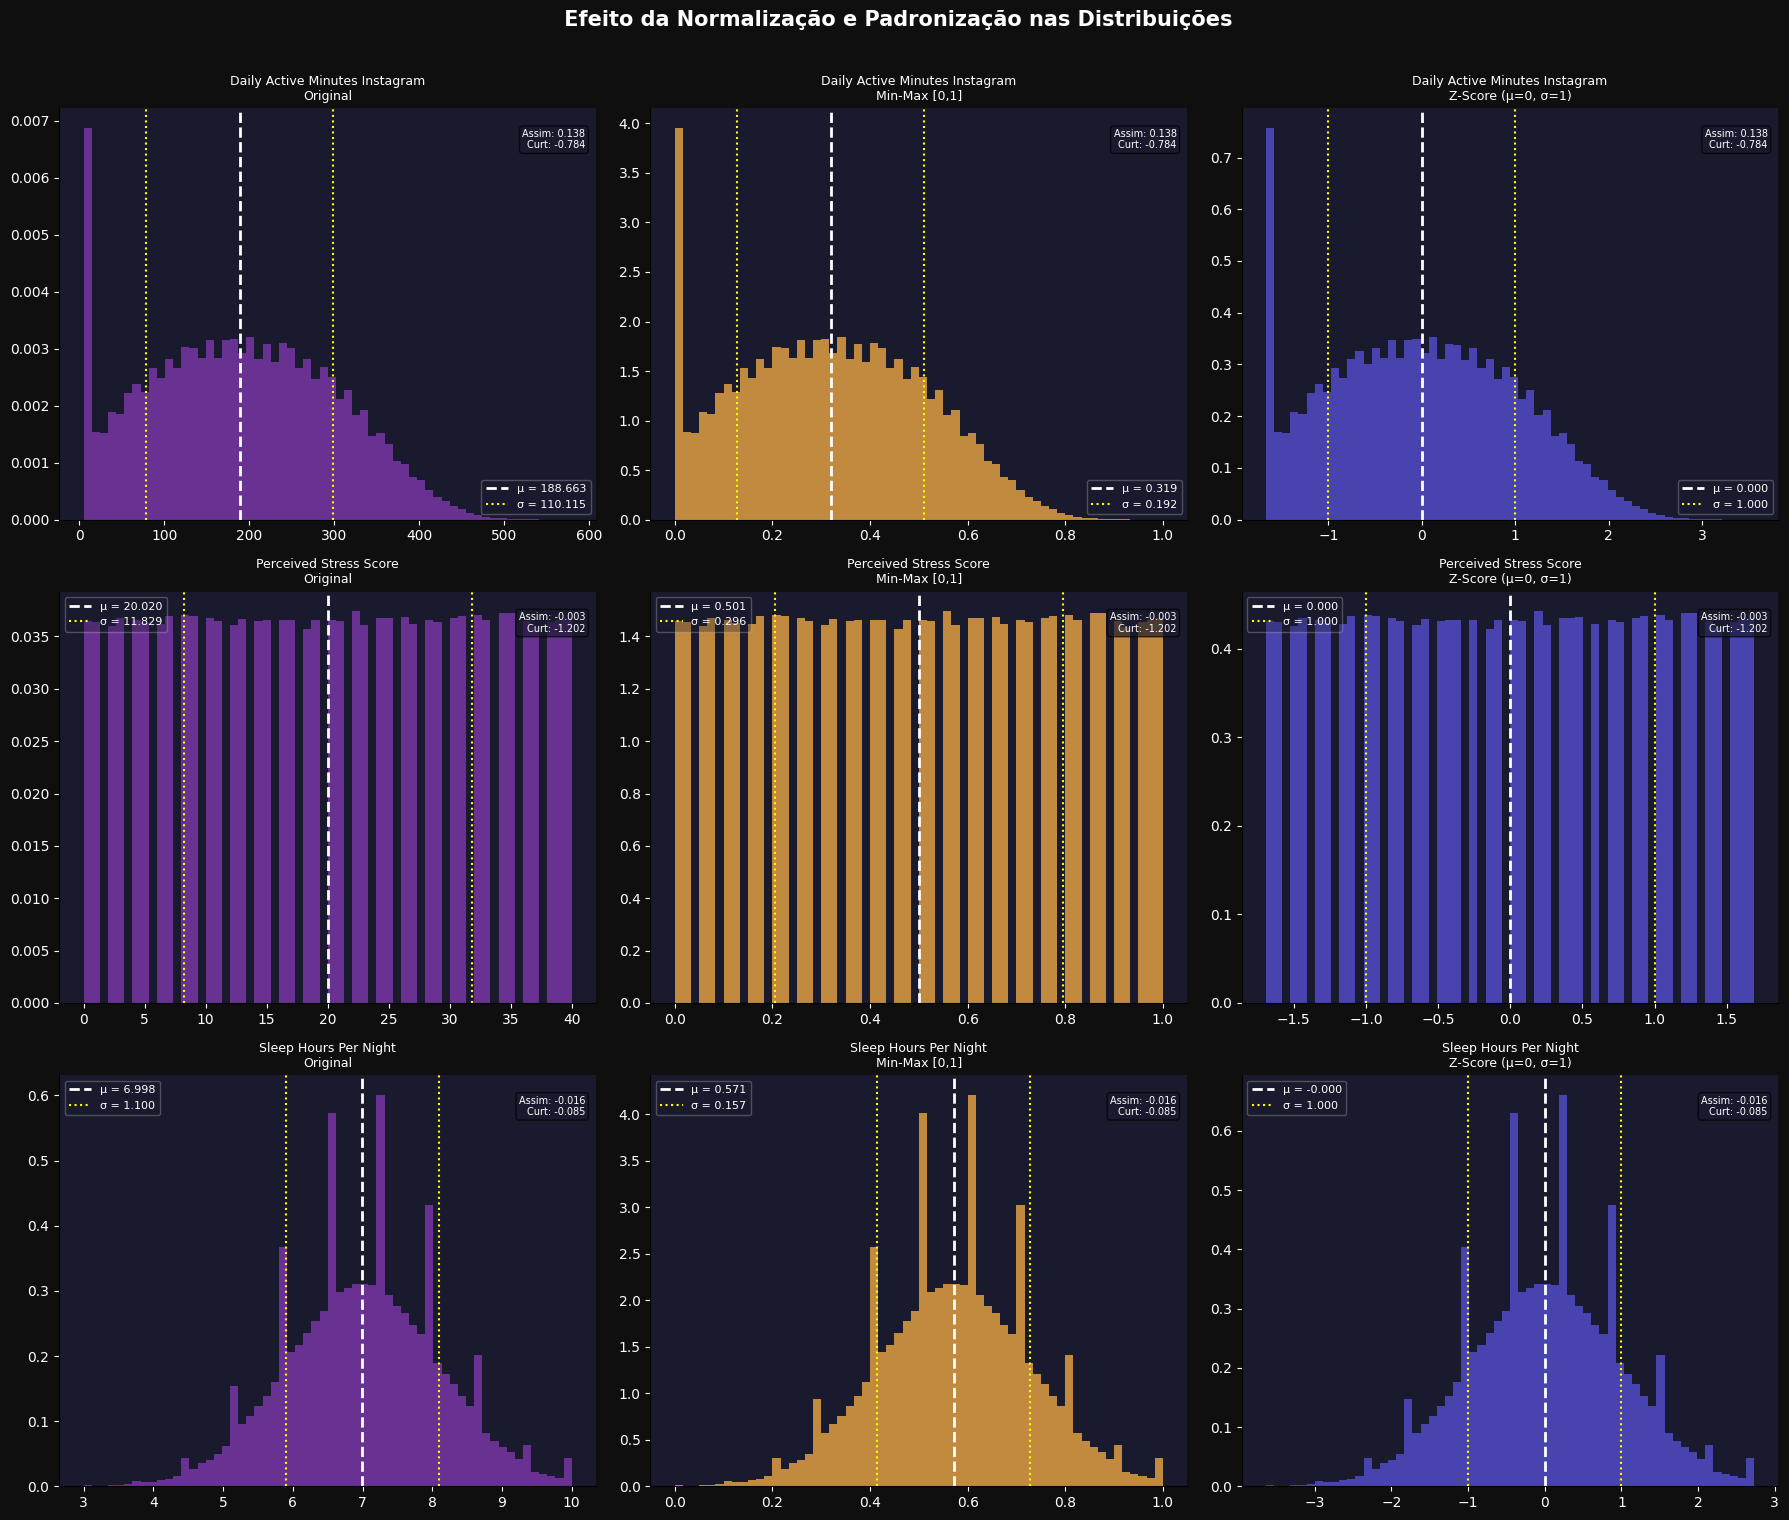

 Guardado: fig_normalizacao.png


In [7]:
# ============================================================
# GRÁFICO — DISTRIBUIÇÕES ANTES vs DEPOIS
# ============================================================

DEMO_VARS = [
    'daily_active_minutes_instagram',
    'perceived_stress_score',
    'sleep_hours_per_night'
]
DEMO_VARS = [v for v in DEMO_VARS if v in df_num.columns]

fig, axes = plt.subplots(len(DEMO_VARS), 3, figsize=(18, 5 * len(DEMO_VARS)))
fig.suptitle(' Efeito da Normalização e Padronização nas Distribuições',
             fontsize=15, fontweight='bold', y=1.01)

titulos = ['Original', 'Min-Max [0,1]', 'Z-Score (μ=0, σ=1)']
cores   = [INSTA_COLORS[0], INSTA_COLORS[2], INSTA_COLORS[4]]

for i, var in enumerate(DEMO_VARS):
    dados = [
        df_num[var],
        df_normalized[f'{var}_norm'],
        df_standardized[f'{var}_std']
    ]

    for j, (data, titulo, cor) in enumerate(zip(dados, titulos, cores)):
        ax = axes[i][j]
        data_clean = data.dropna()

        ax.hist(data_clean, bins=60, color=cor, alpha=0.75,
                density=True, edgecolor='none')

        media = data_clean.mean()
        dp    = data_clean.std()

        ax.axvline(media, color='white',  ls='--', lw=2,
                   label=f'μ = {media:.3f}')
        ax.axvline(media + dp, color='yellow', ls=':', lw=1.5,
                   label=f'σ = {dp:.3f}')
        ax.axvline(media - dp, color='yellow', ls=':', lw=1.5)

        nome_var = var.replace('_', ' ').title()
        ax.set_title(f'{nome_var}\n{titulo}', fontsize=9)
        ax.legend(fontsize=8, framealpha=0.3)

        # Anotação com assimetria e curtose
        sk = skew(data_clean)
        ku = kurtosis(data_clean)
        ax.annotate(
            f'Assim: {sk:.3f}\nCurt: {ku:.3f}',
            xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=7, color='white',
            bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.7)
        )

plt.tight_layout()
plt.savefig('../data/fig_normalizacao.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_normalizacao.png')

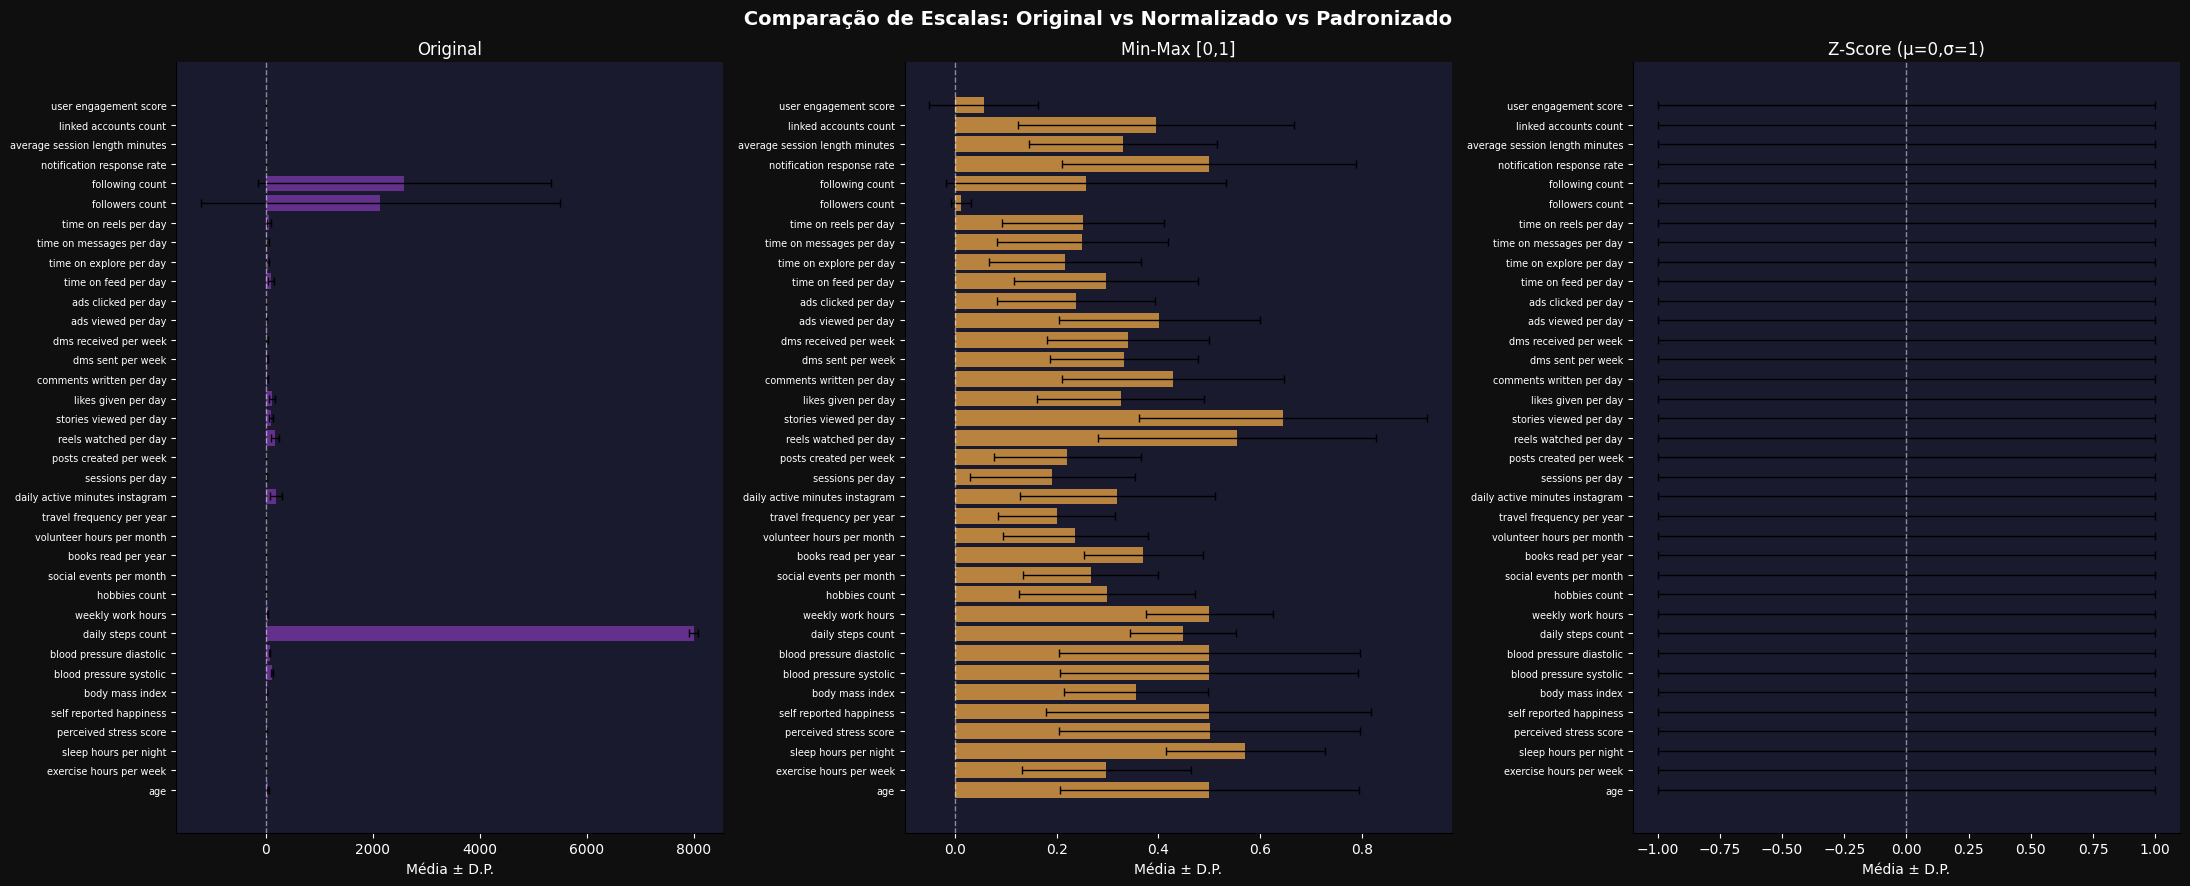

 Guardado: fig_comparacao_escalas.png


In [8]:
# ============================================================
# GRÁFICO — COMPARAÇÃO DE ESCALAS (todas as variáveis)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle(' Comparação de Escalas: Original vs Normalizado vs Padronizado',
             fontsize=14, fontweight='bold')

datasets = [
    (df_num,          'Original',          INSTA_COLORS[0]),
    (df_normalized,   'Min-Max [0,1]',     INSTA_COLORS[2]),
    (df_standardized, 'Z-Score (μ=0,σ=1)', INSTA_COLORS[4]),
]

for ax, (data, titulo, cor) in zip(axes, datasets):
    medias = data.mean()
    dps    = data.std()

    y_pos = range(len(medias))
    ax.barh(y_pos, medias.values, xerr=dps.values,
            color=cor, alpha=0.7, capsize=3,
            error_kw={'color': 'white', 'linewidth': 1})
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        [c.replace('_norm','').replace('_std','').replace('_',' ')
         for c in medias.index],
        fontsize=7
    )
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Média ± D.P.')
    ax.axvline(0, color='white', lw=1, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../data/fig_comparacao_escalas.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_comparacao_escalas.png')

In [9]:
# ============================================================
# ANÁLISE DE NORMALIDADE — SHAPIRO-WILK (amostra)
# ============================================================

print(' TESTE DE NORMALIDADE — Shapiro-Wilk (amostra de 1000)\n')
print(f'{"Variável":<45} {"W (Orig)":>10} {"p (Orig)":>12} {"Normal?":>10}')
print('─' * 80)

# Usa amostra pequena por limitação do Shapiro-Wilk
amostra = df_num.sample(n=min(1000, len(df_num)), random_state=42)

resultados_normalidade = []
for var in VARS_TRANSFORM[:10]:  # Primeiras 10 para não ficar muito longo
    if var not in amostra.columns:
        continue
    data_clean = amostra[var].dropna()
    if len(data_clean) < 3:
        continue
    W, p = shapiro(data_clean)
    normal = ' Sim' if p > 0.05 else ' Não'
    print(f'{var:<45} {W:>10.4f} {p:>12.4e} {normal:>10}')
    resultados_normalidade.append({
        'Variável': var, 'W': round(W, 4),
        'p-value': round(p, 6), 'Normal': p > 0.05
    })

n_normais = sum(r['Normal'] for r in resultados_normalidade)
print(f'\n Variáveis com distribuição normal: {n_normais}/{len(resultados_normalidade)}')
print(' Nota: Shapiro-Wilk é sensível ao tamanho da amostra.')
print('         Com N grande, quase todas as variáveis rejeitam H₀.')

 TESTE DE NORMALIDADE — Shapiro-Wilk (amostra de 1000)

Variável                                        W (Orig)     p (Orig)    Normal?
────────────────────────────────────────────────────────────────────────────────
age                                               0.9549   5.5594e-17        Não
exercise_hours_per_week                           0.9743   2.5778e-12        Não
sleep_hours_per_night                             0.9970   5.5057e-02        Sim
perceived_stress_score                            0.9553   6.8804e-17        Não
self_reported_happiness                           0.9368   3.5594e-20        Não
body_mass_index                                   0.9971   6.7066e-02        Sim
blood_pressure_systolic                           0.9512   1.0789e-17        Não
blood_pressure_diastolic                          0.9534   2.8374e-17        Não
daily_steps_count                                 0.9962   1.5703e-02        Não
weekly_work_hours                                 0.9

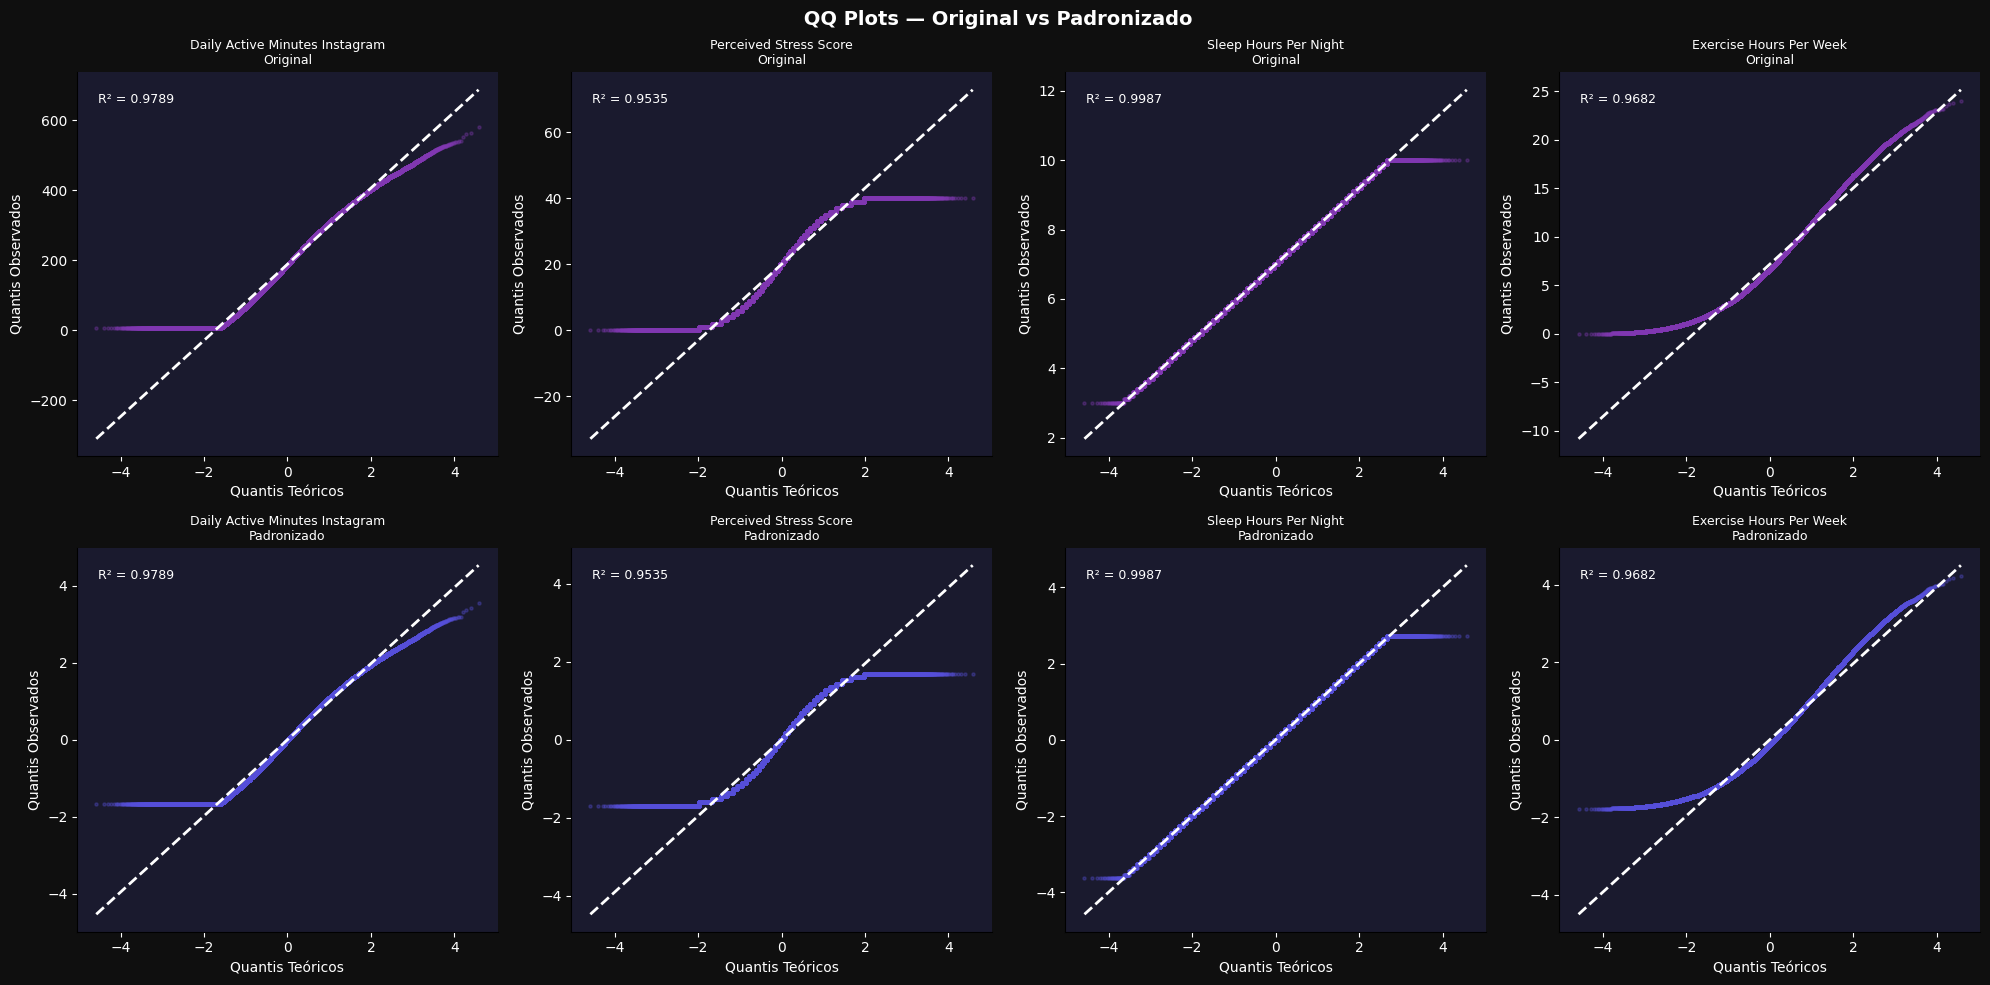

 Guardado: fig_qq_plots.png


In [10]:
# ============================================================
# QQ PLOTS — VERIFICAÇÃO VISUAL DA NORMALIDADE
# ============================================================

from scipy import stats as scipy_stats

DEMO_QQ = [
    'daily_active_minutes_instagram',
    'perceived_stress_score',
    'sleep_hours_per_night',
    'exercise_hours_per_week'
]
DEMO_QQ = [v for v in DEMO_QQ if v in df_num.columns]

fig, axes = plt.subplots(2, len(DEMO_QQ), figsize=(5 * len(DEMO_QQ), 10))
fig.suptitle(' QQ Plots — Original vs Padronizado', fontsize=14, fontweight='bold')

for i, var in enumerate(DEMO_QQ):
    # Original
    data_orig = df_num[var].dropna()
    (osm, osr), (slope, intercept, r) = scipy_stats.probplot(data_orig)
    axes[0][i].scatter(osm, osr, color=INSTA_COLORS[0], alpha=0.3, s=5)
    axes[0][i].plot(
        [osm.min(), osm.max()],
        [slope * osm.min() + intercept, slope * osm.max() + intercept],
        color='white', lw=2, ls='--'
    )
    axes[0][i].set_title(f'{var.replace("_"," ").title()}\nOriginal', fontsize=9)
    axes[0][i].set_xlabel('Quantis Teóricos')
    axes[0][i].set_ylabel('Quantis Observados')
    axes[0][i].annotate(f'R² = {r**2:.4f}', xy=(0.05, 0.92),
                        xycoords='axes fraction', color='white', fontsize=9)

    # Padronizado
    data_std = df_standardized[f'{var}_std'].dropna()
    (osm2, osr2), (slope2, intercept2, r2) = scipy_stats.probplot(data_std)
    axes[1][i].scatter(osm2, osr2, color=INSTA_COLORS[4], alpha=0.3, s=5)
    axes[1][i].plot(
        [osm2.min(), osm2.max()],
        [slope2 * osm2.min() + intercept2, slope2 * osm2.max() + intercept2],
        color='white', lw=2, ls='--'
    )
    axes[1][i].set_title(f'{var.replace("_"," ").title()}\nPadronizado', fontsize=9)
    axes[1][i].set_xlabel('Quantis Teóricos')
    axes[1][i].set_ylabel('Quantis Observados')
    axes[1][i].annotate(f'R² = {r2**2:.4f}', xy=(0.05, 0.92),
                        xycoords='axes fraction', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('../data/fig_qq_plots.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_qq_plots.png')

In [11]:
# ============================================================
# GUIA — QUANDO USAR CADA TÉCNICA
# ============================================================

print('='*65)
print('   GUIA: QUANDO USAR CADA TÉCNICA')
print('='*65)

guia = [
    ('K-Means Clustering',  'Min-Max',  'Baseado em distâncias — escala [0,1] garante equidade'),
    ('PCA',                 'Z-Score',  'Assume variáveis centradas em zero'),
    ('Regressão Linear',    'Z-Score',  'Coeficientes comparáveis, convergência mais rápida'),
    ('Random Forest',       'Nenhuma',  'Baseado em árvores — insensível à escala'),
    ('KNN',                 'Min-Max',  'Baseado em distâncias — sensível à escala'),
    ('SVM',                 'Z-Score',  'Maximização da margem beneficia de dados centrados'),
    ('Redes Neuronais',     'Min-Max',  'Valores em [0,1] facilitam a convergência'),
    ('Regressão Logística', 'Z-Score',  'Convergência mais estável com dados padronizados'),
]

print(f'\n{"Algoritmo":<25} {"Técnica":<12} {"Justificação"}')
print('─' * 85)
for alg, tec, just in guia:
    print(f'{alg:<25} {tec:<12} {just}')

print(f'\n Para a Parte II deste trabalho:')
print(f'   • Clustering (K-Means)  → usar Min-Max Normalization')
print(f'   • PCA + Regressão       → usar Z-Score Standardization')
print(f'   • Random Forest         → dados originais (sem transformação)')

   GUIA: QUANDO USAR CADA TÉCNICA

Algoritmo                 Técnica      Justificação
─────────────────────────────────────────────────────────────────────────────────────
K-Means Clustering        Min-Max      Baseado em distâncias — escala [0,1] garante equidade
PCA                       Z-Score      Assume variáveis centradas em zero
Regressão Linear          Z-Score      Coeficientes comparáveis, convergência mais rápida
Random Forest             Nenhuma      Baseado em árvores — insensível à escala
KNN                       Min-Max      Baseado em distâncias — sensível à escala
SVM                       Z-Score      Maximização da margem beneficia de dados centrados
Redes Neuronais           Min-Max      Valores em [0,1] facilitam a convergência
Regressão Logística       Z-Score      Convergência mais estável com dados padronizados

 Para a Parte II deste trabalho:
   • Clustering (K-Means)  → usar Min-Max Normalization
   • PCA + Regressão       → usar Z-Score Standardization
  

In [12]:
# ============================================================
# EXPORTAÇÃO
# ============================================================

# Adiciona colunas normalizadas e padronizadas ao dataset
df_final = df.copy()

for var in VARS_TRANSFORM:
    if var in df_num.columns:
        df_final[f'{var}_norm'] = df_normalized[f'{var}_norm'].values
        df_final[f'{var}_std']  = df_standardized[f'{var}_std'].values

# Guarda versão completa
df_final.to_csv('../data/instagram_final.csv', index=False)

# Guarda só as normalizadas
df_normalized.to_csv('../data/instagram_normalized.csv', index=False)
df_standardized.to_csv('../data/instagram_standardized.csv', index=False)

# Guarda tabela comparativa
comparacao.to_csv('../data/normalization_stats.csv')

print(' Ficheiros exportados:')
print('   • data/instagram_final.csv        → dataset completo com todas as colunas')
print('   • data/instagram_normalized.csv   → só colunas Min-Max')
print('   • data/instagram_standardized.csv → só colunas Z-Score')
print('   • data/normalization_stats.csv    → tabela comparativa')

print(f'\n RESUMO FINAL DOS 7 NOTEBOOKS:')
print('─' * 50)
notebooks = [
    ('01_dataset_description',          ''),
    ('02_numeric_variables',            ''),
    ('03_qualitative_variables',        ''),
    ('04_binary_variables',             ''),
    ('05_correlations',                 ''),
    ('06_new_variables',                ''),
    ('07_normalization_standardization',''),
]
for nb, status in notebooks:
    print(f'   {status} {nb}')

 Ficheiros exportados:
   • data/instagram_final.csv        → dataset completo com todas as colunas
   • data/instagram_normalized.csv   → só colunas Min-Max
   • data/instagram_standardized.csv → só colunas Z-Score
   • data/normalization_stats.csv    → tabela comparativa

 RESUMO FINAL DOS 7 NOTEBOOKS:
──────────────────────────────────────────────────
    01_dataset_description
    02_numeric_variables
    03_qualitative_variables
    04_binary_variables
    05_correlations
    06_new_variables
    07_normalization_standardization


# Análise Crítica

## Principais Conclusões

- Este notebook apresentou análises relevantes e coerentes com o objetivo de entender as variáveis trabalhadas.
- Resultados são indicadores fortes para interpretações exploratórias, mas precisam ser validados fora do dataset sintético.

## Limitações

- Dataset sintético reduz generalização para cenários reais.
- Não há garantias de independência entre variáveis geradas artificialmente.
- Não existe análise temporal profunda no conjunto atual.

## Recomendação

- Complementar com dados reais e amostras representativas.
- Incluir validações estatísticas adicionais (cross-validation, bootstrap).
- Documentar impactos das transformações e critérios de limpeza.
